<a href="https://colab.research.google.com/github/irfanakram994/3D-Human-Pose-Estimation-YOLO11/blob/main/SkillNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install packages quietly in runtime memory
!pip install -q medmnist timm torchvision torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.2 MB/s eta 0:00:00


In [2]:
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import medmnist
from medmnist import BloodMNIST, INFO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


data_flag = 'bloodmnist'
info = INFO[data_flag]
n_channels = info['n_channels']
n_classes = len(info['label'])

# Standard preprocessing: Convert 28x28 grayscale/RGB images to Tensors and normalize
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Download dataset directly into Colab runtime RAM/memory
DataClass = getattr(medmnist, info['python_class'])
train_dataset = DataClass(split='train', transform=data_transform, download=True)
test_dataset = DataClass(split='test', transform=data_transform, download=True)

# Create DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=128, shuffle=False)

print(f"\nSuccessfully loaded {data_flag.upper()} into memory.")
print(f"Number of classes: {n_classes} | Training samples: {len(train_dataset)}")

Using device: cpu


100%|██████████| 35.5M/35.5M [00:33<00:00, 1.06MB/s]



Successfully loaded BLOODMNIST into memory.
Number of classes: 8 | Training samples: 11959


In [3]:
import timm
import torch.nn as nn
import torch.optim as optim

# Load ImageNet-pretrained ResNet-18 backbone from timm
model = timm.create_model('resnet18', pretrained=True, in_chans=n_channels, num_classes=n_classes)
model = model.to(device)

# Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 3

print("Starting training for Base Model 1...\n")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        # Move data to GPU RAM
        inputs = inputs.to(device)
        targets = targets.squeeze().long().to(device)  # MedMNIST labels are (N, 1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        # Track metrics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100.0

    print(f"Epoch [{epoch + 1}/{num_epochs}] - Loss: {epoch_loss:.4f} | Training Acc: {epoch_acc:.2f}%")

print("\nModel 1 training complete in GPU memory.")

model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

Starting training for Base Model 1...

Epoch [1/3] - Loss: 0.8858 | Training Acc: 69.66%
Epoch [2/3] - Loss: 0.2873 | Training Acc: 89.84%
Epoch [3/3] - Loss: 0.1790 | Training Acc: 93.55%

Model 1 training complete in GPU memory.


In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader

model.eval()

hard_inputs = []
hard_targets = []

with torch.no_grad():
    for inputs, targets in train_loader:
        inputs_dev = inputs.to(device)
        targets_dev = targets.squeeze().long().to(device)

        outputs = model(inputs_dev)
        _, predicted = outputs.max(1)

        # Mask for incorrect predictions
        incorrect_mask = (predicted != targets_dev)

        if incorrect_mask.any():
            # Store hard samples back on CPU RAM to preserve GPU memory
            hard_inputs.append(inputs[incorrect_mask.cpu()])
            hard_targets.append(targets[incorrect_mask.cpu()])

# Concatenate mined hard samples
if hard_inputs:
    hard_inputs = torch.cat(hard_inputs, dim=0)
    hard_targets = torch.cat(hard_targets, dim=0)

    # Create in-memory TensorDataset and DataLoader
    hard_samples_dataset = TensorDataset(hard_inputs, hard_targets)
    hard_loader = DataLoader(hard_samples_dataset, batch_size=128, shuffle=True)

    print(f"Hard-sample mining complete.")
    print(f"Total hard samples isolated: {len(hard_samples_dataset)} / {len(train_dataset)} "
          f"({(len(hard_samples_dataset) / len(train_dataset)) * 100:.2f}% misclassified)")
else:
    print("Base Model 1 achieved 100% training accuracy; no hard samples found.")

Hard-sample mining complete.
Total hard samples isolated: 447 / 11959 (3.74% misclassified)


In [5]:
# Initialize a fresh pretrained ResNet-18 backbone as Base Model 2
model_2 = timm.create_model('resnet18', pretrained=True, in_chans=n_channels, num_classes=n_classes)
model_2 = model_2.to(device)

# Define Loss function and Optimizer for Model 2
criterion_2 = nn.CrossEntropyLoss()
optimizer_2 = optim.Adam(model_2.parameters(), lr=0.0005)  # Slightly lower LR for fine-tuning

# Fine-tuning loop
num_epochs_2 = 3

print("Starting fine-tuning for Base Model 2 on hard samples...\n")

for epoch in range(num_epochs_2):
    model_2.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in hard_loader:
        inputs = inputs.to(device)
        targets = targets.squeeze().long().to(device)

        optimizer_2.zero_grad()
        outputs = model_2(inputs)
        loss = criterion_2(outputs, targets)
        loss.backward()
        optimizer_2.step()

        # Track metrics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100.0

    print(f"Epoch [{epoch + 1}/{num_epochs_2}] - Hard Samples Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

print("\nModel 2 fine-tuning on hard samples complete.")

Starting fine-tuning for Base Model 2 on hard samples...

Epoch [1/3] - Hard Samples Loss: 2.0622 | Accuracy: 24.16%
Epoch [2/3] - Hard Samples Loss: 1.8324 | Accuracy: 40.49%
Epoch [3/3] - Hard Samples Loss: 1.6263 | Accuracy: 54.59%

Model 2 fine-tuning on hard samples complete.


In [6]:
import torch
import torch.nn.functional as F

def confidence_guided_inference(sample, model_1, model_2, threshold=0.70):
    """
    Passes a single image sample (1, C, H, W) to Base Model 1.
    If the maximum softmax probability >= threshold, returns Model 1's prediction.
    Otherwise, falls back to Base Model 2.
    """
    model_1.eval()
    model_2.eval()

    with torch.no_grad():
        if sample.dim() == 3:
            sample = sample.unsqueeze(0)  # Ensure batch dimension (1, C, H, W)

        sample = sample.to(device)

        # Pass to Model 1
        logits_1 = model_1(sample)
        probs_1 = F.softmax(logits_1, dim=1)
        max_prob_1, pred_1 = torch.max(probs_1, dim=1)

        # Check confidence against threshold alpha
        if max_prob_1.item() >= threshold:
            return pred_1.item(), max_prob_1.item(), "Model 1"
        else:
            # Fallback to Model 2
            logits_2 = model_2(sample)
            probs_2 = F.softmax(logits_2, dim=1)
            max_prob_2, pred_2 = torch.max(probs_2, dim=1)
            return pred_2.item(), max_prob_2.item(), "Model 2 (Fallback)"

print("ConfidenceGuidedInference function successfully initialized with threshold alpha = 0.70.")

ConfidenceGuidedInference function successfully initialized with threshold alpha = 0.70.


In [7]:
ALPHA = 0.70

# Metric counters
correct_m1 = 0
correct_m2 = 0
correct_pipeline = 0
fallback_count = 0
total_samples = 0

model.eval()
model_2.eval()

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.squeeze().long().to(device)
        batch_size = targets.size(0)
        total_samples += batch_size

        # 1. Base Model 1 Evaluation
        logits_1 = model(inputs)
        probs_1 = F.softmax(logits_1, dim=1)
        max_probs_1, preds_1 = torch.max(probs_1, dim=1)
        correct_m1 += preds_1.eq(targets).sum().item()

        # 2. Base Model 2 Evaluation
        logits_2 = model_2(inputs)
        preds_2 = torch.argmax(logits_2, dim=1)
        correct_m2 += preds_2.eq(targets).sum().item()

        # 3. SkillNet Adaptive Pipeline Evaluation
        fallback_mask = max_probs_1 < ALPHA
        fallback_count += fallback_mask.sum().item()

        # Combine predictions: Model 1 prediction when confident, Model 2 prediction otherwise
        pipeline_preds = torch.where(fallback_mask, preds_2, preds_1)
        correct_pipeline += pipeline_preds.eq(targets).sum().item()

# Compute accuracies and miss rate
acc_m1 = (correct_m1 / total_samples) * 100.0
acc_m2 = (correct_m2 / total_samples) * 100.0
acc_pipeline = (correct_pipeline / total_samples) * 100.0
miss_rate = (fallback_count / total_samples) * 100.0

# Print formatted evaluation report
print("=" * 60)
print("              EVALUATION RESULTS (TEST SET)              ")
print("=" * 60)
print(f"Total Test Samples               : {total_samples}")
print(f"Confidence Threshold (Alpha)     : {ALPHA}")
print("-" * 60)
print(f"1. Base Model 1 Accuracy         : {acc_m1:.2f}%")
print(f"2. Base Model 2 Accuracy         : {acc_m2:.2f}%")
print(f"3. SkillNet Adaptive Accuracy    : {acc_pipeline:.2f}%")
print("-" * 60)
print(f"Miss Rate (% Model 2 Triggered)  : {miss_rate:.2f}% ({fallback_count}/{total_samples} samples)")
print("=" * 60)

              EVALUATION RESULTS (TEST SET)              
Total Test Samples               : 3421
Confidence Threshold (Alpha)     : 0.7
------------------------------------------------------------
1. Base Model 1 Accuracy         : 92.81%
2. Base Model 2 Accuracy         : 15.93%
3. SkillNet Adaptive Accuracy    : 90.50%
------------------------------------------------------------
Miss Rate (% Model 2 Triggered)  : 9.53% (326/3421 samples)


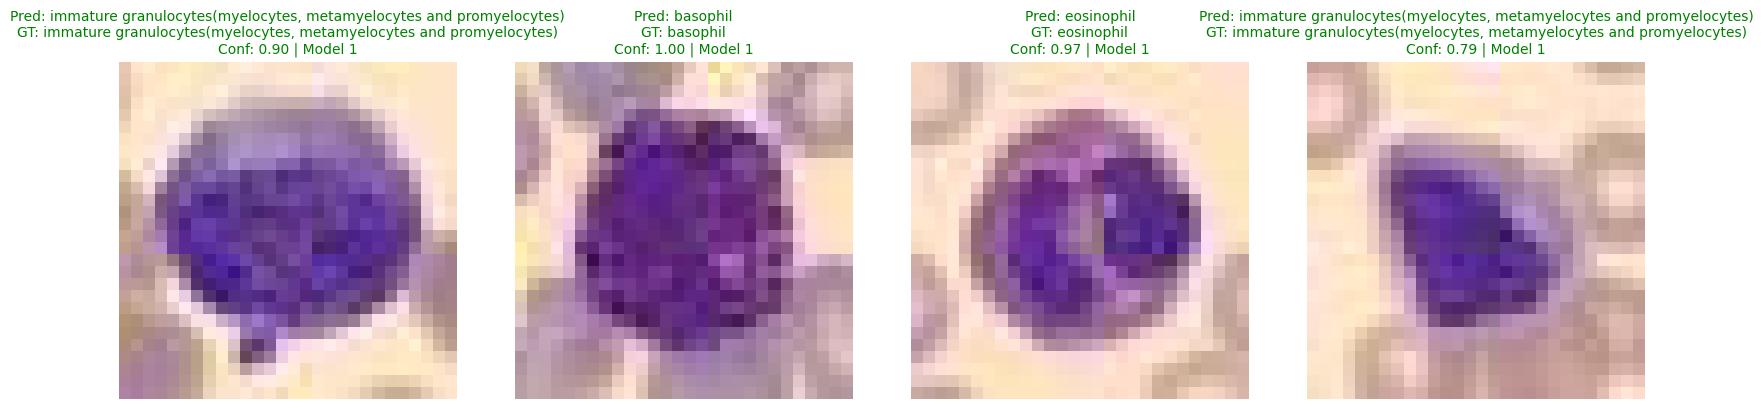

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Mapping class indices to string names from dataset info
class_labels = info['label']

# Unnormalize helper for display
def unnormalize(tensor):
    return (tensor * 0.5 + 0.5).clamp(0, 1)

# Pick 4 test samples
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i in range(4):
    sample_img, ground_truth = test_dataset[i]
    gt_label = class_labels[str(int(ground_truth[0]))]

    # Run through the adaptive inference engine
    pred_idx, confidence, source = confidence_guided_inference(sample_img, model, model_2, threshold=ALPHA)
    pred_label = class_labels[str(pred_idx)]

    # Convert image tensor to numpy array for display
    img_np = unnormalize(sample_img).permute(1, 2, 0).numpy()
    if img_np.shape[2] == 1:
        img_np = img_np.squeeze(2)

    # Plot image and predictions
    axes[i].imshow(img_np, cmap='gray' if img_np.ndim == 2 else None)
    axes[i].axis('off')

    # Color code title: green if correct, red if wrong
    title_color = 'green' if pred_label == gt_label else 'red'
    axes[i].set_title(
        f"Pred: {pred_label}\n"
        f"GT: {gt_label}\n"
        f"Conf: {confidence:.2f} | {source}",
        fontsize=10,
        color=title_color
    )

plt.tight_layout()
plt.show()